In [225]:
import pickle
import numpy as np
import pandas as pd
from hmmlearn import hmm
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [226]:
train_data = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/working_data/5s_0.5.csv')
test_data = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/meta_test_data/5s_0.5.csv')

features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_5s_yo_0.5.csv')

with open('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/imb_files/final_hpt_choices.pkl', 'rb') as f:
    final_choices = pickle.load(f)

Get the groups in the test data to make sure that the same experiments are selected as the true label for validating the state-space classifier.

In [227]:
groups = test_data['experiment_id']

features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
features_test = features[features['experiment_id'].isin(groups)]

X_test_3_class = features_test.drop(['experiment_id', 'label'], axis=1)
y_test_3_class = features_test['label']

In [228]:
# Prepare training and testing data
X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']

In [229]:
# Get the tuned model parameters, selected model and imbalanced handling technique
tuned_model_imb_params = final_choices['5s_0.5']
params = tuned_model_imb_params['params']

In [230]:
# model = RandomForestClassifier(
#         n_estimators=int(params['n_estimators']),
#         max_depth=int(params['max_depth']),
#         min_samples_split=int(params['min_samples_split']),
#         min_samples_leaf=int(params['min_samples_leaf']),
#         max_features=params['max_features'],
#         bootstrap=params['bootstrap']
#     )

In [231]:
# # Apply the sampler
# sampler = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

In [232]:
# # Encode labels
# label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train_resampled)

In [233]:
# model.fit(X_train_resampled, y_train_encoded)
# y_pred = label_encoder.inverse_transform(model.predict(X_test))

In [234]:
# class_names = ['void', 'non-void']
# # Confusion matrix
# cm = confusion_matrix(y_test, y_pred, labels=class_names)
# cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['void', 'non-void'])
# cm_display.plot()
# plt.title(f'Confusion Matrix: 5s_0.5')
# plt.show()
    
    
# print(f"Classification Report: 5s_0.5")
# print(classification_report(y_test, y_pred, labels=class_names))
# print("Accuracy:", accuracy_score(y_test, y_pred))

In [235]:
# y_pred_prob = model.predict_proba(X_test)

In [236]:
# y_pred_prob


In [237]:
# y_pred_prob_df = pd.DataFrame(y_pred_prob, columns=class_names)
# y_pred_prob_df['experiment_id'] = test_data['experiment_id'].values
# y_pred_prob_df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_probabilities.csv', index=False)

In [238]:
def hmm_state_classifier_c(void_probs, n_states=3):
    """
    Use HMM with XGBoost probabilities as observations
    States: 0=pre-void, 1=void, 2=post-void
    """

    # Reshape for hmmlearn (needs 2D array)
    observations = void_probs.reshape(-1, 1)

    # Create HMM model
    model = hmm.GaussianHMM(n_components=n_states, covariance_type="full")

    # Define state transition constraints
    # pre-void -> void -> post-void (mostly forward progression)
    transmat = np.array([
        [0.85, 0.15, 0.0],    # pre-void: mostly stay, can go to void
        [0.0, 0.85, 0.15],    # void: mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void: terminal state
    ])

    model.transmat_ = transmat

    # Set initial state probabilities (always start in pre-void)
    model.startprob_ = np.array([1.0, 0.0, 0.0])

    # Set emission parameters based on expected probabilities
    # Pre-void: low void probability
    # Void: high void probability  
    # Post-void: low void probability
    model.means_ = np.array([[0.2], [0.8], [0.2]])  # Expected P(void) for each state
    model.covars_ = np.array([[[0.1]], [[0.1]], [[0.1]]])  # Variance

    # Predict most likely state sequence
    hidden_states = model.predict(observations)

    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]

    return state_sequence

In [239]:

import numpy as np
import pandas as pd

def hmm_state_classifier_c_df(df, prob_col='void', id_col='experiment_id', n_states=3):
    """
    Use HMM with XGBoost probabilities as observations.
    Handles multiple sequences (experiments) by running the HMM per ID.
    
    States: 0=pre-void, 1=void, 2=post-void
    """
    
    # Define HMM parameters once
    model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", init_params="")
    # model.transmat_ = np.array([
    #     [0.9, 0.1, 0.0],    # pre-void -> mostly stay, can go to void
    #     [0.0, 0.8, 0.2],    # void -> mostly stay, can go to post-void
    #     [0.0, 0.0, 1.0]     # post-void -> terminal
    # ])
    
    model.transmat_ = np.array([
        [0.7, 0.3, 0.0],    # pre-void -> mostly stay, can go to void
        [0.0, 0.90, 0.1],    # void -> mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void -> terminal
    ])
    
    model.startprob_ = np.array([1.0, 0.0, 0.0])
    model.means_ = np.array([[0.2], [0.8], [0.2]])
    model.covars_ = np.array([[[0.1]], [[0.1]], [[0.1]]])

    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []

    # Process each experiment separately
    for exp_id, group in df.groupby(id_col):
        observations = group[prob_col].to_numpy().reshape(-1, 1)
        hidden_states = model.predict(observations)
        state_sequence = [state_map[s] for s in hidden_states]
        
        # Store results with original index to preserve order
        group_result = group.copy()
        group_result['predicted_state'] = state_sequence
        all_results.append(group_result)

    # Combine back into one dataframe
    # return pd.concat(all_results).sort_index()
    return pd.concat(all_results)

In [240]:
import numpy as np
from hmmlearn import hmm


def implementation_2(df, prob_col='void', id_col='experiment_id', n_states=3):
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]
    emissionprob = np.array([
        [0.9, 0.1],  # pre-void mostly emits non-void
        [0.2, 0.8],  # void mostly emits void
        [0.8, 0.2]   # post-void mostly emits non-void again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob


    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    all_results = []
    
    for exp_id, group in df.groupby(id_col):
        # observations = group[prob_col].to_numpy().reshape(-1, 1)
        observations = (group[prob_col] >= 0.37).astype(int).to_numpy().reshape(-1, 1)
        # Step 4: Decode hidden states
        logprob, hidden_states = model.decode(observations, algorithm="viterbi")
        state_sequence = [state_map[s] for s in hidden_states]
        
        # Store results with original index to preserve order
        group_result = group.copy()
        group_result['predicted_state'] = state_sequence
        all_results.append(group_result)
        

    # Combine back into one dataframe
    # return pd.concat(all_results).sort_index()
    return pd.concat(all_results)

In [241]:
probs = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_probabilities_correct_order.csv')


In [242]:
void_probs_exp_ids = probs.drop(columns=['non-void'])
df = hmm_state_classifier_c_df(void_probs_exp_ids, n_states=3)
state_preds = df['predicted_state'].values
df

,void,experiment_id,predicted_state
0,0.387671,5,pre-void
1,0.367105,5,pre-void
2,0.346253,5,pre-void
3,0.566022,5,void
4,0.465052,5,void
...,...,...,...
238,0.679714,41,void
239,0.445729,41,void
240,0.368495,41,void
241,0.482327,41,void


In [243]:
void_probs = probs[probs['experiment_id'] == 40]['void'].values
test_state_preds = hmm_state_classifier_c(void_probs, n_states=3)
# test_state_preds

In [244]:
# probs['experiment_id'].values

In [245]:
accuracy_score(state_preds, y_test_3_class)

0.7654320987654321

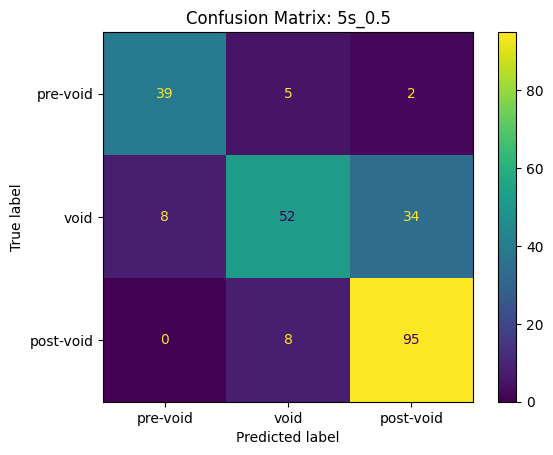

In [246]:
# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

In [247]:
# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))

              precision    recall  f1-score   support

    pre-void       0.83      0.85      0.84        46
        void       0.80      0.55      0.65        94
   post-void       0.73      0.92      0.81       103

    accuracy                           0.77       243
   macro avg       0.78      0.77      0.77       243
weighted avg       0.77      0.77      0.76       243

Accuracy: 0.7654320987654321


In [248]:
# probs['void'].values

In [249]:
df = implementation_2(void_probs_exp_ids, n_states=3)
state_preds = df['predicted_state'].values
df

,void,experiment_id,predicted_state
0,0.387671,5,pre-void
1,0.367105,5,pre-void
2,0.346253,5,pre-void
3,0.566022,5,void
4,0.465052,5,void
...,...,...,...
238,0.679714,41,void
239,0.445729,41,void
240,0.368495,41,void
241,0.482327,41,void


In [250]:
accuracy_score(state_preds, y_test_3_class)

0.831275720164609

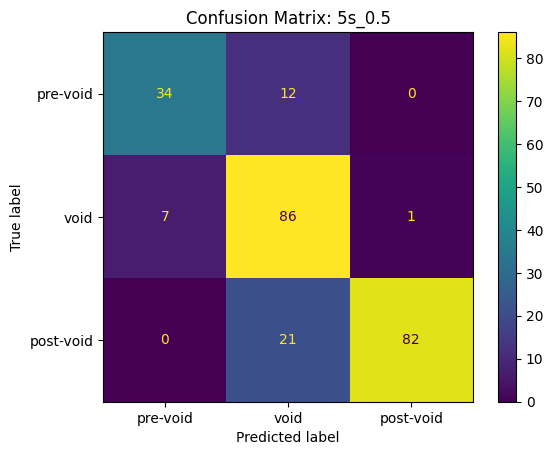

In [251]:
# Confusion matrix
cm = confusion_matrix(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void'])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pre-void', 'void', 'post-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()

In [252]:
# Classification report
print(classification_report(y_test_3_class, state_preds, labels=['pre-void', 'void', 'post-void']))
print("Accuracy:", accuracy_score(y_test_3_class, state_preds))

              precision    recall  f1-score   support

    pre-void       0.83      0.74      0.78        46
        void       0.72      0.91      0.81        94
   post-void       0.99      0.80      0.88       103

    accuracy                           0.83       243
   macro avg       0.85      0.82      0.82       243
weighted avg       0.86      0.83      0.83       243

Accuracy: 0.831275720164609
